In [1]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\hp\Downloads\tested.csv")

In [2]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
df.shape

(418, 12)

In [6]:
df.drop("Cabin",axis=1,inplace=True)

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S


In [8]:
df=df.drop("Ticket",axis=1)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Fare         417 non-null    float64
 9   Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 46.3 KB


In [10]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [11]:
df["Fare"]=df["Fare"].fillna(df["Fare"].median())

In [12]:
df.duplicated("PassengerId").sum()

np.int64(0)

In [13]:
df["Age"]=df["Age"].astype(int)

In [14]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,29.574163,0.447368,0.392344,35.576535
std,120.810458,0.481622,0.841838,12.721533,0.896760,0.981429,55.850103
min,892.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.471875
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [15]:
for col in ["Survived", "SibSp", "Parch","Fare"]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers capped to [{lower:.1f} – {upper:.1f}]")

    df[col] = df[col].clip(lower=lower, upper=upper)     #medain place of clip 

Survived: 0 outliers capped to [-1.5 – 2.5]
SibSp: 11 outliers capped to [-1.5 – 2.5]
Parch: 94 outliers capped to [0.0 – 0.0]
Fare: 55 outliers capped to [-27.5 – 66.8]


In [16]:
q1=df["Survived"].quantile(0.25)
print(q1)
q3=df["Survived"].quantile(0.75)
print(q3)

0.0
1.0


In [17]:
df["familysize"]=df["SibSp"]+df["Parch"]+1
print(df["familysize"].head(4))

0    1.0
1    2.0
2    1.0
3    1.0
Name: familysize, dtype: float64


In [18]:
df[['SibSp', 'Parch', 'familysize']] = df[['SibSp', 'Parch', 'familysize']].astype(int)


In [19]:
df["Name"]

0                                  Kelly, Mr. James
1                  Wilkes, Mrs. James (Ellen Needs)
2                         Myles, Mr. Thomas Francis
3                                  Wirz, Mr. Albert
4      Hirvonen, Mrs. Alexander (Helga E Lindqvist)
                           ...                     
413                              Spector, Mr. Woolf
414                    Oliva y Ocana, Dona. Fermina
415                    Saether, Mr. Simon Sivertsen
416                             Ware, Mr. Frederick
417                        Peter, Master. Michael J
Name: Name, Length: 418, dtype: str

In [20]:
df["Title"] = df["Name"].str.extract(r'([A-Za-z]+)\.', expand=False)
df["LastName"] = df["Name"].str.split(",").str[0]
df["FirstName"] = df["Name"].str.split(",").str[1].str.split(".").str[1]

In [21]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,familysize,Title,LastName,FirstName
0,892,0,3,"Kelly, Mr. James",male,34,0,0,7.829200,Q,1,Mr,Kelly,James
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,7.000000,S,2,Mrs,Wilkes,James (Ellen Needs)
2,894,0,2,"Myles, Mr. Thomas Francis",male,62,0,0,9.687500,Q,1,Mr,Myles,Thomas Francis
3,895,0,3,"Wirz, Mr. Albert",male,27,0,0,8.662500,S,1,Mr,Wirz,Albert
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,0,12.287500,S,2,Mrs,Hirvonen,Alexander (Helga E Lindqvist)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27,0,0,8.050000,S,1,Mr,Spector,Woolf
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39,0,0,66.835988,C,1,Dona,Oliva y Ocana,Fermina
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38,0,0,7.250000,S,1,Mr,Saether,Simon Sivertsen
416,1308,0,3,"Ware, Mr. Frederick",male,27,0,0,8.050000,S,1,Mr,Ware,Frederick


# Compare variables with target (Survived):

In [22]:
df.groupby("Pclass")["Survived"].sum().sort_values(ascending=False)

Pclass
3    72
1    50
2    30
Name: Survived, dtype: int64

In [23]:
x=["Pclass","Sex","familysize"]
for i in x:
    a=df.groupby(i)["Survived"].mean().sort_values(ascending=False)
    print(a)

Pclass
1    0.467290
3    0.330275
2    0.322581
Name: Survived, dtype: float64
Sex
female    1.0
male      0.0
Name: Survived, dtype: float64
familysize
2    0.490909
3    0.400000
1    0.310954
Name: Survived, dtype: float64


In [24]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100])
df.groupby("AgeGroup")["Survived"].mean()

AgeGroup
(0, 12]      0.500000
(12, 18]     0.406250
(18, 35]     0.335938
(35, 60]     0.389474
(60, 100]    0.400000
Name: Survived, dtype: float64

In [25]:
df["FareGroup"] = pd.qcut(df["Fare"], 4)
df.groupby("FareGroup")["Survived"].mean().sort_values(ascending=False)

FareGroup
(31.472, 66.836]    0.523810
(14.454, 31.472]    0.401961
(7.896, 14.454]     0.268041
(-0.001, 7.896]     0.263158
Name: Survived, dtype: float64

In [26]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100])
df["FareGroup"] = pd.qcut(df["Fare"], 4)

In [27]:
df.groupby(["AgeGroup", "FareGroup"])["Survived"].agg(["mean", "count"])

mean  count
AgeGroup  FareGroup                        
(0, 12]   (-0.001, 7.896]   0.000000      1
          (7.896, 14.454]   1.000000      2
          (14.454, 31.472]  0.416667     12
          (31.472, 66.836]  0.600000      5
(12, 18]  (-0.001, 7.896]   0.666667      9
          (7.896, 14.454]   0.300000     10
          (14.454, 31.472]  0.333333      3
          (31.472, 66.836]  0.300000     10
(18, 35]  (-0.001, 7.896]   0.204301     93
          (7.896, 14.454]   0.279412     68
          (14.454, 31.472]  0.456140     57
          (31.472, 66.836]  0.578947     38
(35, 60]  (-0.001, 7.896]   0.454545     11
          (7.896, 14.454]   0.166667     12
          (14.454, 31.472]  0.230769     26
          (31.472, 66.836]  0.521739     46
(60, 100] (7.896, 14.454]   0.000000      2
          (14.454, 31.472]  0.500000      2
          (31.472, 66.836]  0.500000      6

In [28]:
df.groupby(["Pclass", "Sex"])["Survived"].mean().sort_values(ascending=False)

Pclass  Sex   
1       female    1.0
2       female    1.0
3       female    1.0
1       male      0.0
2       male      0.0
3       male      0.0
Name: Survived, dtype: float64

In [29]:
df.groupby(["Pclass", "Sex"])["Survived"].agg(["mean", "count"])

mean  count
Pclass Sex                
1      female   1.0     50
       male     0.0     57
2      female   1.0     30
       male     0.0     63
3      female   1.0     72
       male     0.0    146

# corr

In [30]:
#it is only used for numerical values
corr = df[["Survived","Pclass","familysize"]].corr()
print(corr.round(2))

            Survived  Pclass  familysize
Survived        1.00   -0.11        0.13
Pclass         -0.11    1.00       -0.08
familysize      0.13   -0.08        1.00


In [31]:
v=df.groupby("familysize")["Survived"].mean()
print(v)

familysize
1    0.310954
2    0.490909
3    0.400000
Name: Survived, dtype: float64


# Data Visualization

In [32]:
#Histogram (Age, Fare)
#Count plots (Gender, Class)
#Bar plots (Survival rates)

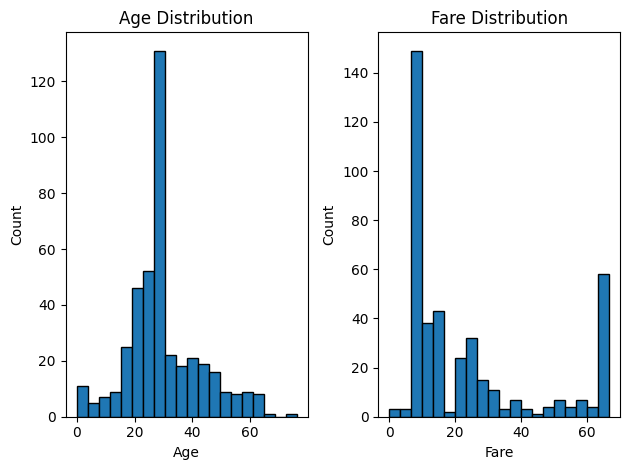

In [33]:
import matplotlib.pyplot as plt
# Create the first subplot (1 row, 2 columns, position 1)
plt.subplot(1,2,1)  
plt.hist(df["Age"],bins=20,edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(df["Fare"], bins=20,edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


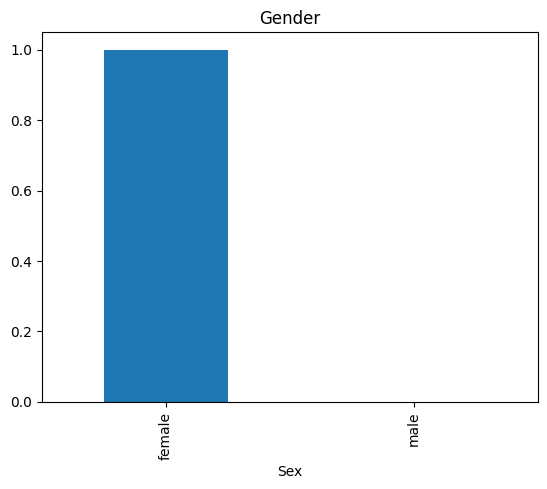

In [34]:
df.groupby("Sex")["Survived"].mean().sort_values(ascending=False).plot(kind="bar")
#plt.subplot(1,2,1)
#plt.bar(df["Survived"].value_counts(),height=2)
plt.title("Gender")

df.groupby("Sex")["Survived"].mean().sort_values(ascending=False).plot(kind="bar")



plt.show()



In [35]:
df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

Sex
female    1.0
male      0.0
Name: Survived, dtype: float64

(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '3'), Text(2, 0, '2')])

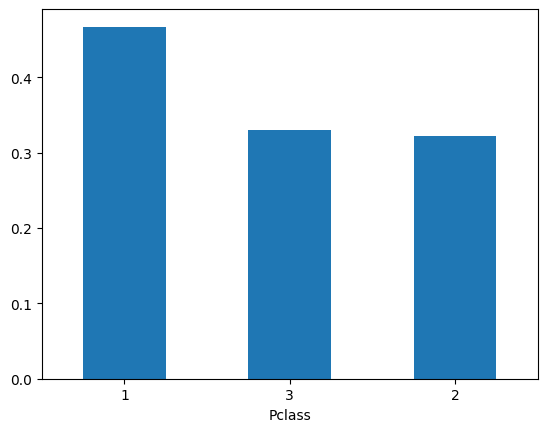

In [36]:
df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False).plot(kind="bar")
plt.xticks(rotation=0)

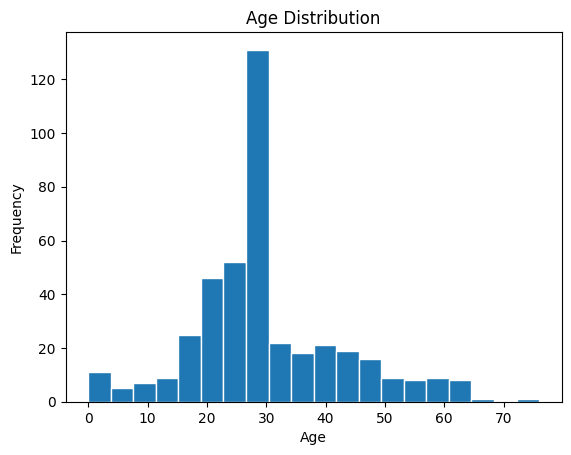

In [37]:
plt.hist(df['Age'].dropna(), bins=20,edgecolor="white")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

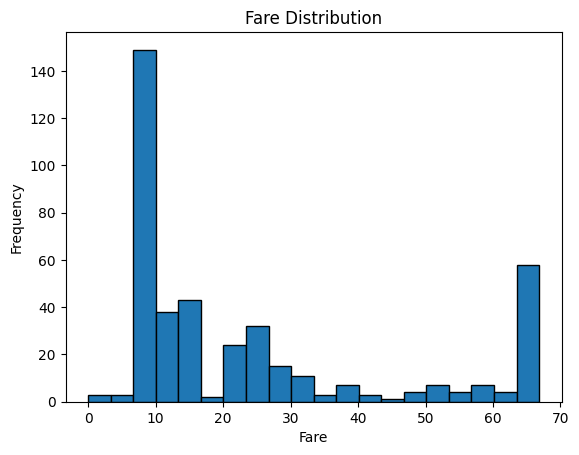

In [38]:
plt.hist(df['Fare'], bins=20,edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

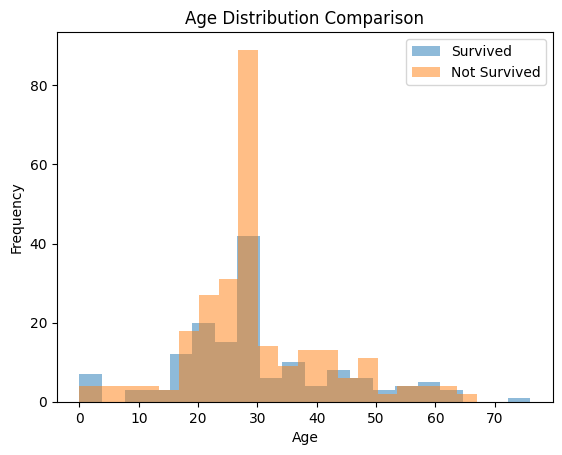

In [39]:
survived = df[df['Survived'] == 1]['Age'].dropna()
not_survived = df[df['Survived'] == 0]['Age'].dropna()

plt.hist(survived, bins=20, alpha=0.5, label='Survived')
plt.hist(not_survived, bins=20, alpha=0.5, label='Not Survived')

plt.title("Age Distribution Comparison")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()
#age compare b/w survived and non survived

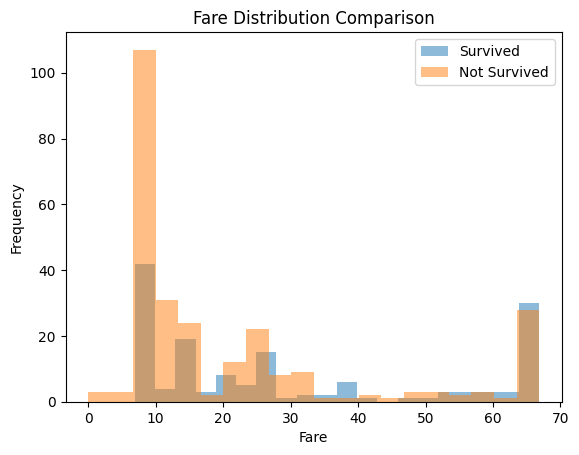

In [40]:
survived_fare = df[df['Survived'] == 1]['Fare']
not_survived_fare = df[df['Survived'] == 0]['Fare']

plt.hist(survived_fare, bins=20, alpha=0.5, label='Survived')
plt.hist(not_survived_fare, bins=20, alpha=0.5, label='Not Survived')

plt.title("Fare Distribution Comparison")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [41]:
gender_survival= df.groupby(['Sex', 'Survived']).size().unstack()
print(gender_survival)

Survived      0      1
Sex                   
female      NaN  152.0
male      266.0    NaN


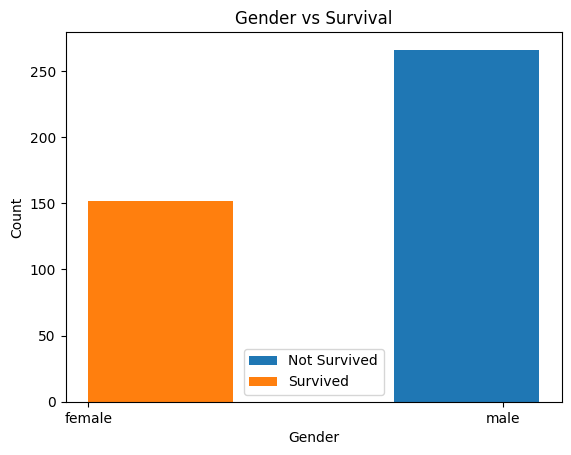

In [42]:
import numpy as np

gender_survival = df.groupby(['Sex', 'Survived']).size().unstack()

x = np.arange(len(gender_survival.index))
width = 0.35

plt.bar(x - width/4, gender_survival[0], width, label='Not Survived')
plt.bar(x + width/2, gender_survival[1], width, label='Survived')

plt.xticks(x, gender_survival.index)
plt.title("Gender vs Survival")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend()
plt.show()

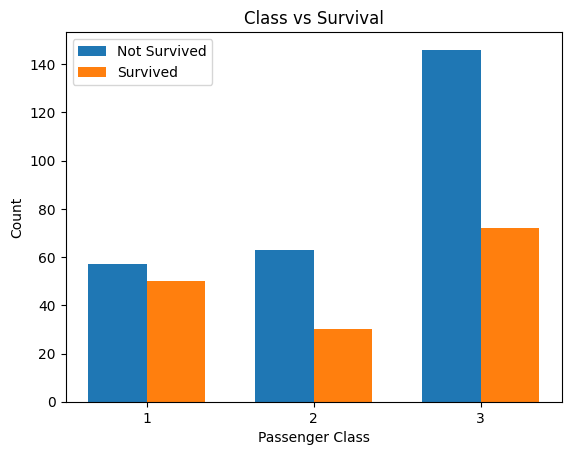

In [43]:
class_survival = df.groupby(['Pclass', 'Survived']).size().unstack()

x = np.arange(len(class_survival.index))
width = 0.35

plt.bar(x - width/2, class_survival[0], width, label='Not Survived')
plt.bar(x + width/2, class_survival[1], width, label='Survived')

plt.xticks(x, class_survival.index)
plt.title("Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12524\1159244513.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([survived_0, survived_1], labels=['Not Survived', 'Survived'])


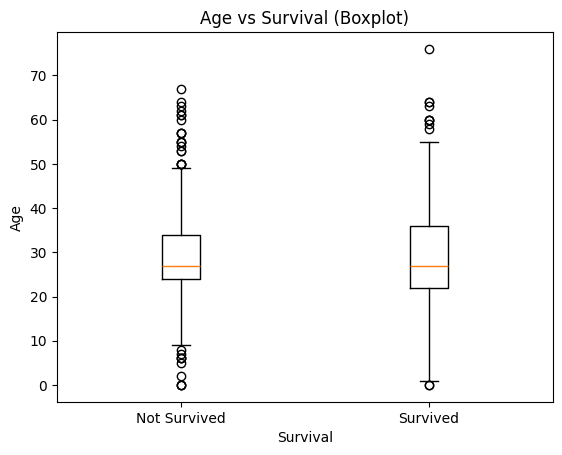

In [44]:
import matplotlib.pyplot as plt

survived_0 = df[df['Survived'] == 0]['Age']
survived_1 = df[df['Survived'] == 1]['Age']
 

plt.boxplot([survived_0, survived_1], labels=['Not Survived', 'Survived'])

plt.title("Age vs Survival (Boxplot)")
plt.xlabel("Survival")
plt.ylabel("Age")
 
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12524\1813456828.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([class1,class2,class3],labels=["Class 1","Class 2","Class 3"])


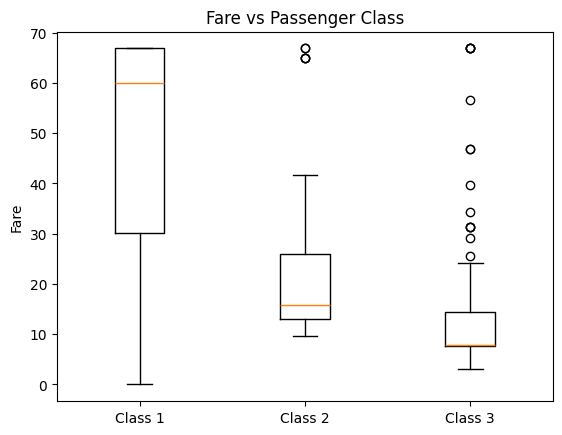

In [45]:
class1=df[df["Pclass"]==1]["Fare"]
class2=df[df["Pclass"]==2]["Fare"]
class3=df[df["Pclass"]==3]["Fare"]

plt.boxplot([class1,class2,class3],labels=["Class 1","Class 2","Class 3"])
plt.title("Fare vs Passenger Class")
plt.ylabel("Fare")
plt.show()    

In [46]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


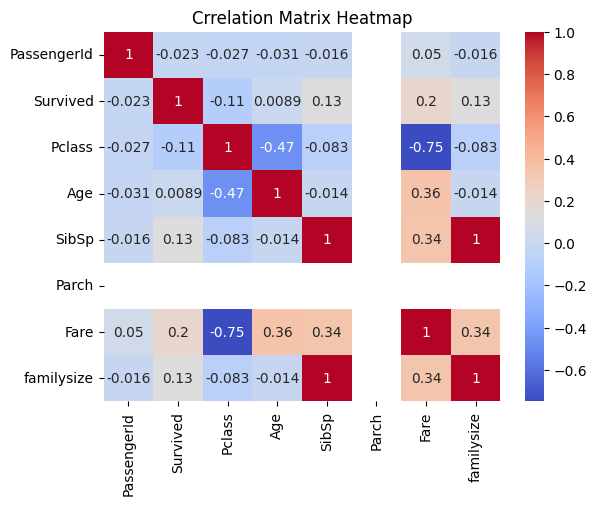

In [47]:
import seaborn as sns 
corr= df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Crrelation Matrix Heatmap")
plt.show()

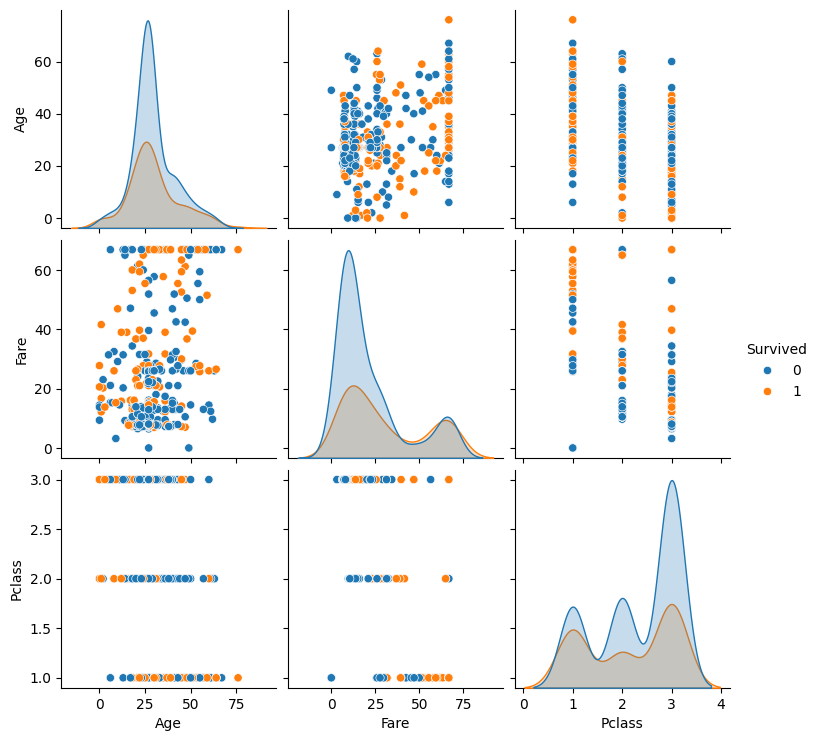

In [48]:
sns.pairplot(df[["Age","Fare","Pclass","Survived"]],hue="Survived")
plt.show()

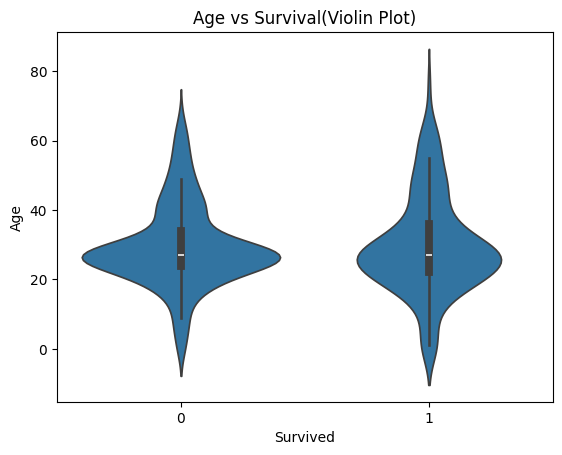

In [49]:
sns.violinplot(x="Survived",y="Age",data=df)
plt.title("Age vs Survival(Violin Plot)")
plt.show()

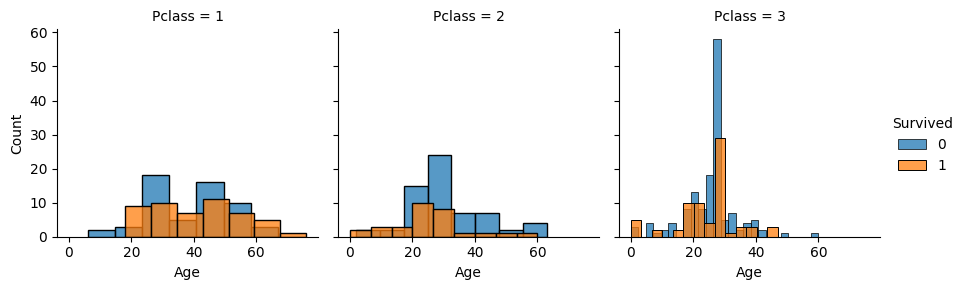

In [50]:
g=sns.FacetGrid(df,col="Pclass",hue="Survived")
g.map(sns.histplot,"Age")
g.add_legend()
plt.show()